# Генерация синтетических данных с использованием Faker

In [2]:
import sys
!{sys.executable} -m pip install faker

  Obtaining dependency information for faker from https://files.pythonhosted.org/packages/64/5f/824e6fb3e9d63408151dc9173994fa65bde620a67dde3a59354f5aecd497/faker-40.23.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.0 MB 1.1 MB/s eta 0:00:02
   - -------------------------------------- 0.1/2.0 MB 1.1 MB/s eta 0:00:02
   ---- ----------------------------------- 0.2/2.0 MB 1.4 MB/s eta 0:00:02
   ---- ----------------------------------- 0.2/2.0 MB 1.4 MB/s eta 0:00:02
   --------- ------------------------------ 0.5/2.0 MB 2.0 MB/s eta 0:00:01
   --------- ------------------------------ 0.5/2.0 MB 2.0 MB/s eta 0:00:01
   ------------------ --------------------- 0.9/2.0 MB 3.0 MB/s eta 0:00:01
   ---------------------------- ----------- 1.4/2.0 MB 3.5 MB/s eta 0:00:01
   ------------------------------ --------- 1.5/2.0 MB 3.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

In [4]:
# Инициализация генератора (русская локаль для реалистичных ФИО, адресов и т.д.)
fake = Faker('ru_RU')
Faker.seed(42)      # фиксируем seed для воспроизводимости
random.seed(42)

## Генерация синтетических данных для варианта "Сотрудники компании"

In [5]:
# DataFrame с отделами
def generate_departments(n):
   
    departments = []
    for i in range(1, n + 1):
        departments.append({
            'department_id': i,
            'name': fake.unique.job() + ' отдел',  # уникальное название
            'location': fake.city()
        })
    return pd.DataFrame(departments)

# DataFrame с должностями и диапазоном зарплат
def generate_positions(n: int) -> pd.DataFrame:
    
    positions = []
    for i in range(1, n + 1):
        min_salary = random.randint(30000, 60000)
        max_salary = min_salary + random.randint(20000, 80000)
        positions.append({
            'position_id': i,
            'name': fake.unique.job(),
            'min_salary': min_salary,
            'max_salary': max_salary
        })
    return pd.DataFrame(positions)

# генерируем сотрудников со случайными атрибутами
def generate_employees(n: int, department_ids: list, position_ids: list) -> pd.DataFrame:
    
    employees = []
    for emp_id in range(1, n + 1):        
        first_name = fake.first_name()
        last_name = fake.last_name()
        patronymic = fake.middle_name()
        birth_date = fake.date_of_birth(minimum_age=18, maximum_age=70)
        phone = fake.phone_number()
        email = fake.email()
        address = fake.address().replace('\n', ', ')
        
        # дата найма: не раньше 18-летия и не позже сегодняшнего дня
        min_hire_date = birth_date + timedelta(days=18*365)
        hire_date = fake.date_between(start_date=min_hire_date, end_date='today')
        
        # статус -  active / terminated (10% уволены)
        status = random.choices(['active', 'terminated'], weights=[0.9, 0.1])[0]
        
        # выбор отдела и должности
        department_id = random.choice(department_ids)
        position_id = random.choice(position_ids)
        
        # зарплата     
        salary = random.randint(40000, 150000)
        
        employees.append({
            'employee_id': emp_id,
            'last_name': last_name,
            'first_name': first_name,
            'patronymic': patronymic,
            'birth_date': birth_date,
            'gender': random.choice(['М', 'Ж']),
            'address': address,
            'phone': phone,
            'email': email,
            'hire_date': hire_date,
            'status': status,
            'department_id': department_id,
            'position_id': position_id,
            'salary': salary
        })
    return pd.DataFrame(employees)

# создать историю зарплат на основе данных сотрудников
def generate_salary_history(employees_df: pd.DataFrame, avg_records: int = 3):    
    history = []
    record_id = 1
    
    for _, emp in employees_df.iterrows():
        emp_id = emp['employee_id']
        hire_date = emp['hire_date']
        current_salary = emp['salary']
        
        # количество изменений (0 – если сотрудник только нанят и ещё не было изменений)
        num_changes = random.choices([0, 1, 2, 3, 4], weights=[0.2, 0.3, 0.3, 0.1, 0.1])[0]
        
        # генерируем даты изменений (после hire_date и до сегодня)
        change_dates = sorted([fake.date_between(start_date=hire_date, end_date='today') 
                               for _ in range(num_changes)])
        
        # начальная зарплата при найме (можно сделать немного отличающейся от текущей)
        #  будем считать, что первая запись – это зарплата при найме,
        # а последующие – повышения.
        if num_changes == 0:
            # Если изменений не было, всё равно добавим одну запись (начальная)
            history.append({
                'history_id': record_id,
                'employee_id': emp_id,
                'change_date': hire_date,
                'new_salary': current_salary
            })
            record_id += 1
        else:
            # генерируем возрастающие зарплаты
            salary_values = sorted([random.randint(30000, current_salary) for _ in range(num_changes)])
            # добавляем текущую зарплату как последнюю
            salary_values.append(current_salary)
            # даты: hire_date и change_dates
            all_dates = [hire_date] + change_dates
            for i in range(len(all_dates)):
                history.append({
                    'history_id': record_id,
                    'employee_id': emp_id,
                    'change_date': all_dates[i],
                    'new_salary': salary_values[i]
                })
                record_id += 1
    return pd.DataFrame(history)

In [6]:
N_DEPARTMENTS = 10
N_POSITIONS = 20
N_EMPLOYEES = 500

In [7]:
departments_df = generate_departments(N_DEPARTMENTS)
positions_df = generate_positions(N_POSITIONS)
employees_df = generate_employees(
    N_EMPLOYEES,
    departments_df['department_id'].tolist(),
    positions_df['position_id'].tolist()
)

In [8]:
departments_df

,department_id,name,location
0,1,Диетолог отдел,клх Кырен
1,2,Метеоролог отдел,п. Волоколамск
2,3,Гепатолог отдел,г. Артем
3,4,Гомеопат отдел,п. Териберка
4,5,Бактериолог отдел,клх Усинск
5,6,Танцор отдел,с. Чикола
6,7,Нотариус отдел,ст. Ессентуки
7,8,Тележурналист отдел,к. Ельня
8,9,Литейщик отдел,г. Видное
9,10,Сиделка отдел,к. Нефедова


In [9]:
positions_df

,position_id,name,min_salary,max_salary
0,1,Мясник,50952,78248
1,2,Борт-радист,30819,99417
2,3,Философ,39012,75061
3,4,Доярка,37314,66458
4,5,Семейный врач,54132,80849
5,6,Врач скорой помощи,52174,120714
6,7,Ортопед,59234,114975
7,8,Реставратор,32848,91546
8,9,Композитор,43825,65907
9,10,Военный прокурор,30976,57116


In [10]:
employees_df

,employee_id,last_name,first_name,patronymic,birth_date,gender,address,phone,email,hire_date,status,department_id,position_id,salary
0,1,Гаврилов,Мина,Кузьминична,1973-08-22,М,"к. Бологое, пер. Островского, д. 77, 242388",+7 928 327 64 83,tatjana_03@example.org,2009-07-04,active,7,11,76421
1,2,Григорьева,Ольга,Федотович,1995-03-08,Ж,"д. Красногорск (Моск.), ш. Заречное, д. 684 ст...",8 532 871 01 22,erjabova@example.com,2023-10-22,active,6,4,52156
2,3,Крюкова,Лаврентий,Егоровна,1990-01-08,М,"п. Хасавюрт, ул. Вахитова, д. 382, 824896",83252880957,makarovamaja@example.com,2015-03-20,active,6,20,74671
3,4,Лукина,Тимур,Николаевна,2002-06-02,М,"г. Яхрома, алл. Профсоюзная, д. 951, 473829",+7 (465) 787-1331,adrian_98@example.org,2025-04-22,active,9,4,89615
4,5,Мартынов,Савватий,Станиславовна,1987-08-29,М,"п. Уварово, алл. Челюскинцев, д. 84 к. 81, 080132",8 311 656 67 01,maslovalukija@example.org,2019-06-22,active,10,12,115674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Кузнецова,Твердислав,Теймуразович,1992-05-09,Ж,"с. Кажим, бул. Ручейный, д. 1 стр. 1, 669579",+7 (996) 872-25-89,semendementev@example.org,2010-12-29,active,4,16,112173
496,497,Фомина,Амвросий,Валерьевич,1966-11-25,М,"клх Котельнич, алл. Угольная, д. 4/4 стр. 356,...",+78255442867,ikarpov@example.com,1996-12-28,active,8,16,100401
497,498,Гуляев,Мефодий,Владленович,1994-08-19,Ж,"к. Ардон, пр. Механический, д. 9/6 стр. 895, 4...",+7 (693) 358-95-13,vatslav_2008@example.net,2014-08-29,active,6,6,58344
498,499,Корнилова,Евдокия,Якубович,1994-09-26,М,"п. Партизанск, ул. 40 лет Победы, д. 8 к. 455,...",+7 179 720 38 59,karpevseev@example.org,2020-10-25,active,9,2,108674


In [11]:
# Генерация истории зарплат
salary_history_df = generate_salary_history(employees_df, avg_records=3)
salary_history_df

,history_id,employee_id,change_date,new_salary
0,1,1,2009-07-04,71333
1,2,1,2024-01-28,76421
2,3,2,2023-10-22,34948
3,4,2,2025-04-15,52156
4,5,3,2015-03-20,74671
...,...,...,...,...
1291,1292,498,2022-10-27,57426
1292,1293,498,2024-05-16,58344
1293,1294,499,2020-10-25,89827
1294,1295,499,2022-12-05,108674


In [12]:
# Сохранение в CSV
departments_df.to_csv('departments.csv', index=False)
positions_df.to_csv('positions.csv', index=False)
employees_df.to_csv('employees.csv', index=False)
salary_history_df.to_csv('salary_history.csv', index=False)

# Задание на самостоятельную работу
Создать синтетический набор данных, сохранить его в csv файлы, построить на основе данных онтологию, вывести онтограф.


### Вариант 6. Недвижимость и сделки
Сущности: 
- Объект недвижимости: id, адрес, тип (квартира/дом/коммерческое), площадь, количество комнат, этаж, год постройки, кадастровый номер.
- Владелец: id, ФИО, паспортные данные, доля (если долевая собственность).
- Сделка купли-продажи: id, дата, id объекта, id продавца, id покупателя, цена, нотариус.
- Ценовой архив: id объекта, дата изменения, новая цена (для отслеживания динамики).

Объём: 2000 объектов, 300 владельцев, 150 сделок, у каждого объекта 2–3 записи цен.

Онтология:
- Классы: Объект, Владелец, Сделка, ЦеновойАрхив.
- Связи: объект может иметь нескольких владельцев (доли), сделка связывает продавца, покупателя и объект.



In [16]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

# Инициализация генератора с русской локалью для реалистичных ФИО, адресов и номеров машин
fake = Faker('ru_RU')

# Фиксируем seed для того, чтобы при каждом запуске данные генерировались одинаково
Faker.seed(42)      
random.seed(42)

In [17]:
# 1. Владельцы
def generate_owners(n) -> pd.DataFrame:
    owners = []
    for i in range(1, n + 1):
        owners.append({
            'owner_id': i,
            'full_name': fake.name(),
            'passport': f"{random.randint(1000, 9999)} {random.randint(100000, 999999)}",
            # Доля владения (упрощенно как атрибут по заданию)
            'share': random.choice(['1/1', '1/2', '1/3', '1/4'])
        })
    return pd.DataFrame(owners)

# 2. Объекты недвижимости
def generate_objects(n, owner_ids) -> pd.DataFrame:
    objects = []
    for i in range(1, n + 1):
        # Реализация случайного количества владельцев (1 или 2) для объекта
        owners_count = random.choices([1, 2], weights=[0.8, 0.2])[0]
        current_owners = random.sample(owner_ids, owners_count)
        
        objects.append({
            'object_id': i,
            'address': fake.address().replace('\n', ', '),
            'type': random.choice(['квартира', 'дом', 'коммерческое']),
            'area': round(random.uniform(20.0, 500.0), 1),
            'rooms': random.randint(1, 10),
            'floor': random.randint(1, 30),
            'build_year': random.randint(1950, 2024),
            'cadastral_number': f"{random.randint(10,99)}:{random.randint(10,99)}:{random.randint(1000000,9999999)}:{random.randint(10,99)}",
            'owner_ids': ",".join(map(str, current_owners)) # Храним связи с владельцами
        })
    return pd.DataFrame(objects)

# 3. Сделки купли-продажи
def generate_transactions(n, object_ids, owner_ids) -> pd.DataFrame:
    transactions = []
    for i in range(1, n + 1):
        seller = random.choice(owner_ids)
        buyer = random.choice(owner_ids)
        while buyer == seller:
            buyer = random.choice(owner_ids)
            
        transactions.append({
            'transaction_id': i,
            'date': fake.date_between(start_date='-5y', end_date='today'),
            'object_id': random.choice(object_ids),
            'seller_id': seller,
            'buyer_id': buyer,
            'price': random.randint(1500000, 50000000),
            'notary': fake.name()
        })
    return pd.DataFrame(transactions)

# 4. Ценовой архив
def generate_price_archive(object_ids) -> pd.DataFrame:
    archive = []
    archive_id = 1
    for obj_id in object_ids:
        records_count = random.randint(2, 3) # 2-3 записи на объект
        base_price = random.randint(1500000, 45000000)
        
        for _ in range(records_count):
            archive.append({
                'archive_id': archive_id,
                'object_id': obj_id,
                'change_date': fake.date_between(start_date='-10y', end_date='today'),
                'new_price': base_price + random.randint(-500000, 5000000)
            })
            base_price += random.randint(100000, 1000000)
            archive_id += 1
            
    return pd.DataFrame(archive)

In [18]:
N_OBJECTS = 2000
N_OWNERS = 300
N_TRANSACTIONS = 150

# Генерация
owners_df = generate_owners(N_OWNERS)
objects_df = generate_objects(N_OBJECTS, owners_df['owner_id'].tolist())
transactions_df = generate_transactions(N_TRANSACTIONS, objects_df['object_id'].tolist(), owners_df['owner_id'].tolist())
archive_df = generate_price_archive(objects_df['object_id'].tolist())

# Сохранение в CSV
owners_df.to_csv('owners.csv', index=False)
objects_df.to_csv('objects.csv', index=False)
transactions_df.to_csv('transactions.csv', index=False)
archive_df.to_csv('price_archive.csv', index=False)

print(f"Сгенерировано: Объектов - {len(objects_df)}, Владельцев - {len(owners_df)}, Сделок - {len(transactions_df)}, Записей в архиве - {len(archive_df)}")

Сгенерировано: Объектов - 2000, Владельцев - 300, Сделок - 150, Записей в архиве - 4987


In [23]:
owners_df.head()

,owner_id,full_name,passport,share
0,1,Козлова Ирина Ефимовна,2824 126225,1/3
1,2,Зиновьев Варфоломей Афанасьевич,5012 334053,1/2
2,3,Морозова Алевтина Богдановна,2679 809570,1/1
3,4,Селезнев Эраст Адрианович,7912 133326,1/1
4,5,Терентьева София Николаевна,2535 329258,1/2


In [22]:
objects_df.head()

,object_id,address,type,area,rooms,floor,build_year,cadastral_number,owner_ids
0,1,"г. Кисловодск, алл. Коминтерна, д. 6/9 стр. 3/...",дом,218.4,4,17,1996,89:73:8416216:16,278
1,2,"с. Клин, ул. Нахимова, д. 1 к. 5/4, 713900",квартира,465.3,8,29,2012,25:13:5014745:30,282
2,3,"п. Хабаровск, ул. Портовая, д. 63, 904228",коммерческое,215.8,4,27,1964,69:25:3583206:73,8
3,4,"г. Ардон, ул. Фурманова, д. 69, 240268",коммерческое,151.2,8,16,1981,68:80:3426689:59,"150,261"
4,5,"с. Северодвинск, пер. Приозерный, д. 9/4 к. 88...",коммерческое,442.1,2,9,2003,53:74:5482413:10,261


In [24]:
transactions_df.head()

,transaction_id,date,object_id,seller_id,buyer_id,price,notary
0,1,2026-01-19,371,167,88,40722173,Кудряшов Авдей Еремеевич
1,2,2022-01-16,1396,157,88,24738144,Агап Власович Пестов
2,3,2023-11-07,208,72,161,28751582,Поляков Аким Анисимович
3,4,2025-03-31,672,60,258,34333249,Некрасова Наталья Святославовна
4,5,2024-06-12,919,189,44,5966773,Шарова Пелагея Леонидовна


In [25]:
archive_df.head()

,archive_id,object_id,change_date,new_price
0,1,1,2026-01-22,13978944
1,2,1,2023-08-04,14212150
2,3,2,2018-01-20,10205339
3,4,2,2020-10-10,10767396
4,5,3,2018-12-24,44778274


In [27]:
from owlready2 import *
import pandas as pd

onto = get_ontology("http://example.org/traffic_ontology_ru.owl")

with onto:
    # --- Классы ---
    class Владелец(Thing): pass
    class ОбъектНедвижимости(Thing): pass
    class Сделка(Thing): pass
    class ЦеновойАрхив(Thing): pass

    # --- Связи (Object Properties) ---
    class владеет_объектом(ObjectProperty):
        domain = [Владелец]; range = [ОбъектНедвижимости]

    class относится_к_объекту(ObjectProperty):
        domain = [Сделка]; range = [ОбъектНедвижимости]

    class продавец(ObjectProperty):
        domain = [Сделка]; range = [Владелец]

    class покупатель(ObjectProperty):
        domain = [Сделка]; range = [Владелец]

    class архив_привязан_к_объекту(ObjectProperty):
        domain = [ЦеновойАрхив]; range = [ОбъектНедвижимости]

    # --- Атрибуты (Data Properties) ---
    class фио(DataProperty):
        domain = [Владелец]; range = [str]
    class паспорт(DataProperty):
        domain = [Владелец]; range = [str]
    class доля(DataProperty):
        domain = [Владелец]; range = [str]

    class адрес(DataProperty):
        domain = [ОбъектНедвижимости]; range = [str]
    class тип_объекта(DataProperty):
        domain = [ОбъектНедвижимости]; range = [str]
    class площадь(DataProperty):
        domain = [ОбъектНедвижимости]; range = [float]
    class комнаты(DataProperty):
        domain = [ОбъектНедвижимости]; range = [int]
    class кадастровый_номер(DataProperty):
        domain = [ОбъектНедвижимости]; range = [str]

    class дата_сделки(DataProperty):
        domain = [Сделка]; range = [str]
    class цена_сделки(DataProperty):
        domain = [Сделка]; range = [int]
    class нотариус(DataProperty):
        domain = [Сделка]; range = [str]

    class дата_изменения(DataProperty):
        domain = [ЦеновойАрхив]; range = [str]
    class новая_цена(DataProperty):
        domain = [ЦеновойАрхив]; range = [int]

In [28]:
владельцы_инстансы = {}
объекты_инстансы = {}

with onto:
    # 1. Заполняем владельцев
    for _, row in owners_df.iterrows():
        человек = Владелец(f"Владелец_{row['owner_id']}")
        человек.фио = [row['full_name']]
        человек.паспорт = [row['passport']]
        человек.доля = [row['share']]
        владельцы_инстансы[row['owner_id']] = человек

    # 2. Заполняем объекты
    for _, row in objects_df.iterrows():
        объект = ОбъектНедвижимости(f"Объект_{row['object_id']}")
        объект.адрес = [row['address']]
        объект.тип_объекта = [row['type']]
        объект.площадь = [float(row['area'])]
        объект.комнаты = [row['rooms']]
        объект.кадастровый_номер = [row['cadastral_number']]
        
        # Разбор связей с владельцами
        текущие_владельцы = [int(x) for x in str(row['owner_ids']).split(",")]
        for в_id in текущие_владельцы:
            хозяин = владельцы_инстансы.get(в_id)
            if хозяин:
                хозяин.владеет_объектом.append(объект)
                
        объекты_инстансы[row['object_id']] = объект

    # 3. Заполняем сделки
    for _, row in transactions_df.iterrows():
        сделка = Сделка(f"Сделка_{row['transaction_id']}")
        сделка.дата_сделки = [str(row['date'])]
        сделка.цена_сделки = [int(row['price'])]
        сделка.нотариус = [row['notary']]
        
        объект = объекты_инстансы.get(row['object_id'])
        если_продавец = владельцы_инстансы.get(row['seller_id'])
        если_покупатель = владельцы_инстансы.get(row['buyer_id'])
        
        if объект: сделка.относится_к_объекту.append(объект)
        if если_продавец: сделка.продавец.append(если_продавец)
        if если_покупатель: сделка.покупатель.append(если_покупатель)

    # 4. Заполняем ценовой архив
    for _, row in archive_df.iterrows():
        запись = ЦеновойАрхив(f"Архив_{row['archive_id']}")
        запись.дата_изменения = [str(row['change_date'])]
        запись.новая_цена = [int(row['new_price'])]
        
        объект = объекты_инстансы.get(row['object_id'])
        if объект:
            запись.архив_привязан_к_объекту.append(объект)

print("Онтология успешно наполнена данными.")

Онтология успешно наполнена данными.


  Obtaining dependency information for networkx from https://files.pythonhosted.org/packages/9e/c9/b2622292ea83fbb4ec318f5b9ab867d0a28ab43c5717bb85b0a5f6b3b0a4/networkx-3.6.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.1 MB 1.2 MB/s eta 0:00:02
   - -------------------------------------- 0.1/2.1 MB 1.2 MB/s eta 0:00:02
   ---- ----------------------------------- 0.2/2.1 MB 1.4 MB/s eta 0:00:02
   ---- ----------------------------------- 0.2/2.1 MB 1.4 MB/s eta 0:00:02
   --------- ------------------------------ 0.5/2.1 MB 2.1 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.1 MB 3.0 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.1 MB 3.0 MB/s eta


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


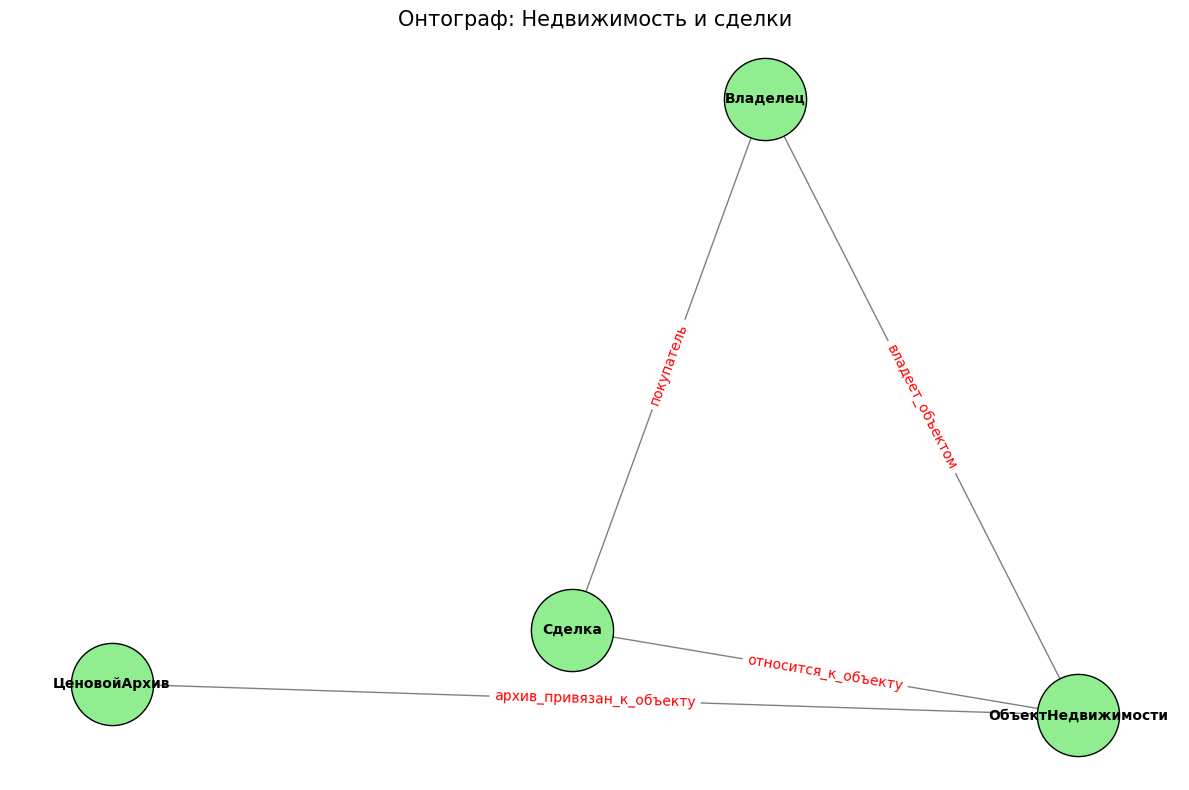

In [31]:
!{sys.executable} -m pip install networkx
import networkx as nx
import matplotlib.pyplot as plt

# Создаем пустой граф
G = nx.DiGraph()

# Проходим по всем классам
for cls in list(onto.classes()):
    G.add_node(cls.name)
    
    # Ищем объектные свойства
    for prop in list(onto.object_properties()):
        if cls in prop.domain:
            for target in prop.range:
                if hasattr(target, 'name'):
                    G.add_edge(cls.name, target.name, label=prop.name)

# Визуализация
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=1.5)

nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='lightgreen', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, edge_color='gray')

edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Онтограф: Недвижимость и сделки", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()